In [1]:

# Cell 0 — Imports and setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.preprocessing import StandardScaler

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_columns', None)

PROCESSED = Path('../data/processed')
FIGDIR = Path('../reports/figures')
FIGDIR.mkdir(parents=True, exist_ok=True)

In [2]:

# Cell 1 — Load artifacts
X_pca = pd.read_csv(PROCESSED / 'X_pca.csv')
context = pd.read_csv(PROCESSED / 'context.csv')
X_cat = pd.read_csv(PROCESSED / 'X_cat.csv')          # optional, for later profiling
inventory = pd.read_csv(PROCESSED / 'column_inventory.csv')

print("X_pca shape :", X_pca.shape)      # expect (1146, 9)
print("context shape:", context.shape)   # expect (1146, 6)
print("\nPCA columns:", X_pca.columns.tolist())

X_pca shape : (1146, 9)
context shape: (1146, 6)

PCA columns: ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9']


In [3]:

# Cell 2 — Sanity checks
assert X_pca.shape[0] == context.shape[0], "Row counts do not match"
assert X_pca.isna().sum().sum() == 0, "X_pca contains NaNs"
print("✓ Matrices are aligned and clean")
print("\nX_pca head:")
display(X_pca.head(3))

✓ Matrices are aligned and clean

X_pca head:


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9
0,-2.707519,0.121899,-3.004961,0.068885,-1.117597,0.057173,0.174364,0.063558,-0.765758
1,0.111108,3.978012,0.421396,-1.235330,-1.394175,1.337498,0.364608,-0.689786,1.039433
2,-1.817090,-1.075932,-2.034788,2.866735,0.924629,0.564087,-0.033000,-0.051152,-0.407266


k =  2  |  inertia = 15,655  |  silhouette = 0.224
k =  3  |  inertia = 13,233  |  silhouette = 0.201
k =  4  |  inertia = 12,052  |  silhouette = 0.172
k =  5  |  inertia = 11,400  |  silhouette = 0.149
k =  6  |  inertia = 10,880  |  silhouette = 0.144
k =  7  |  inertia = 10,414  |  silhouette = 0.137
k =  8  |  inertia = 10,022  |  silhouette = 0.133
k =  9  |  inertia = 9,731  |  silhouette = 0.126
k = 10  |  inertia = 9,465  |  silhouette = 0.126


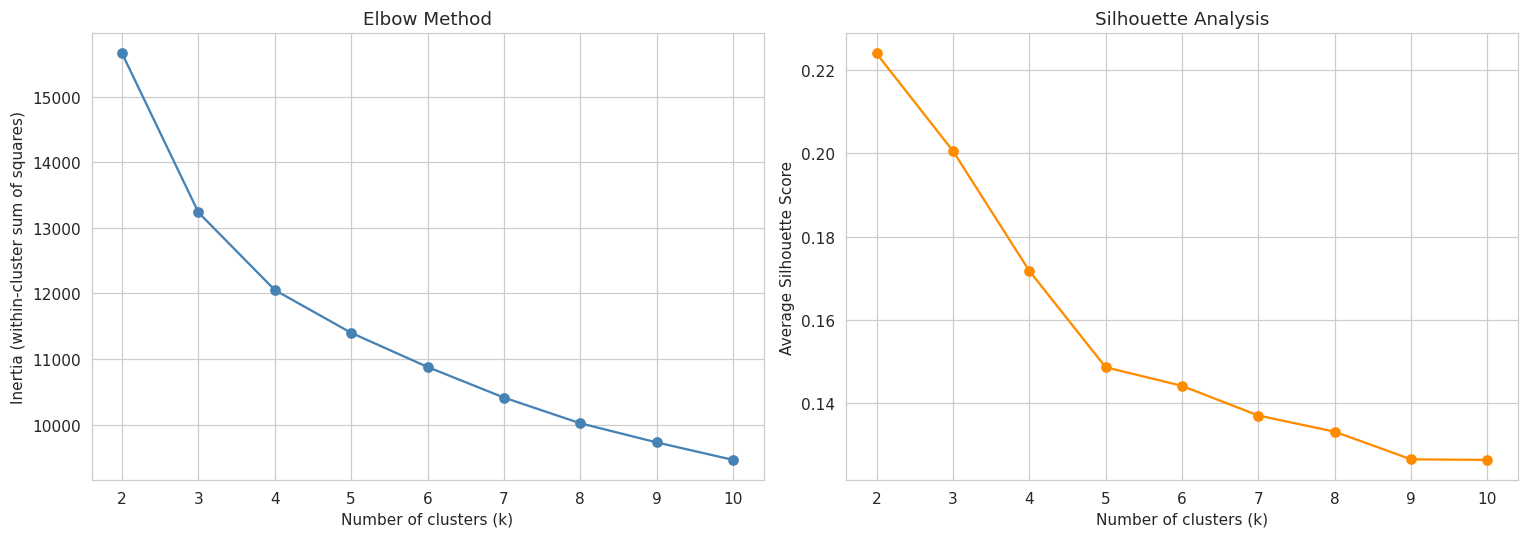

In [4]:

# Cell 3 — Elbow method and Silhouette analysis to choose k
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

K_range = range(2, 11)
inertias = []
silhouettes = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=50)
    labels = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_pca, labels))
    print(f"k = {k:2d}  |  inertia = {km.inertia_:,.0f}  |  silhouette = {silhouettes[-1]:.3f}")

# Plot both metrics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, 'o-', color='steelblue')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia (within-cluster sum of squares)')
axes[0].set_title('Elbow Method')
axes[0].set_xticks(list(K_range))

axes[1].plot(K_range, silhouettes, 'o-', color='darkorange')
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Average Silhouette Score')
axes[1].set_title('Silhouette Analysis')
axes[1].set_xticks(list(K_range))

plt.tight_layout()
plt.savefig(FIGDIR / 'kmeans_elbow_silhouette.png', bbox_inches='tight')
plt.show()

In [5]:
# Cell 4 — Final K-Means model (k = 3)
FINAL_K = 3

# 1. Ensure features matrix excludes target labels
features_only = X_pca.drop(columns=['cluster'], errors='ignore')

# 2. Fit K-Means
kmeans = KMeans(n_clusters=FINAL_K, random_state=42, n_init=50)
cluster_labels = kmeans.fit_predict(features_only)

# 3. Calculate metrics before mutating DataFrames
score = silhouette_score(features_only, cluster_labels)

# 4. Attach cluster labels
for df in (X_pca, context, X_cat):
    df['cluster'] = cluster_labels

# 5. Output summary
print("Cluster sizes:")
print(pd.Series(cluster_labels).value_counts().sort_index())
print(f"\nFinal inertia: {kmeans.inertia_:,.0f}")
print(f"Silhouette score: {score:.3f}")

Cluster sizes:
0    319
1    445
2    382
Name: count, dtype: int64

Final inertia: 13,233
Silhouette score: 0.201


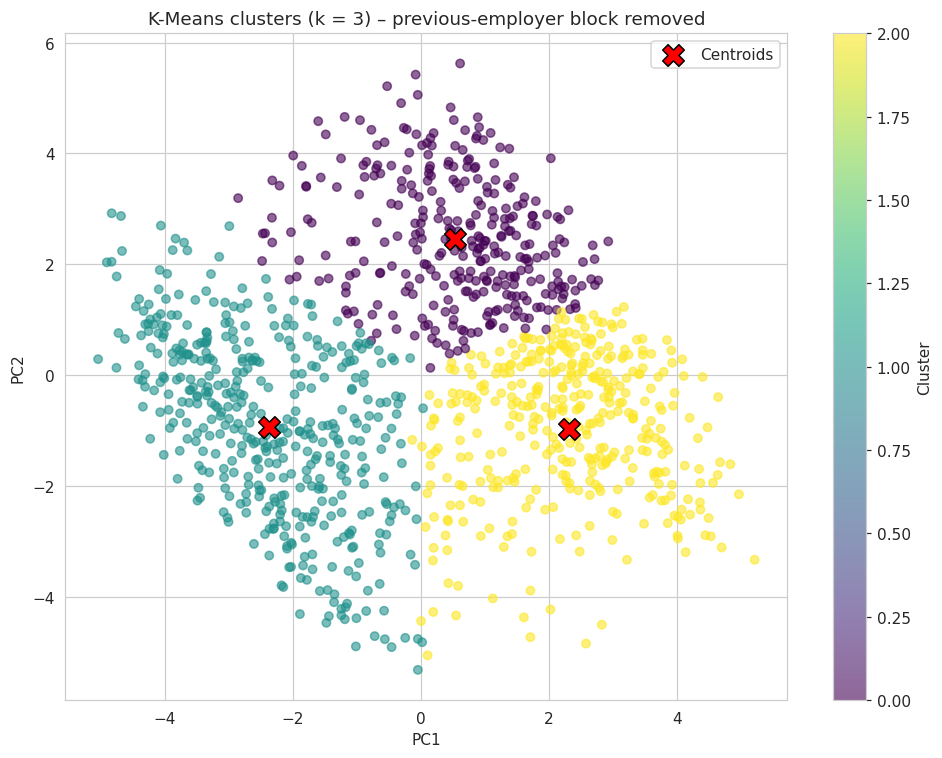

In [6]:

# Cell 5 — 2-D scatter coloured by cluster (updated labels)
fig, ax = plt.subplots(figsize=(9, 7))

scatter = ax.scatter(
    X_pca['PC1'], X_pca['PC2'],
    c=X_pca['cluster'],
    cmap='viridis',
    alpha=0.6,
    s=30
)

centroids = kmeans.cluster_centers_
ax.scatter(
    centroids[:, 0], centroids[:, 1],
    c='red', marker='X', s=200, edgecolors='black', label='Centroids'
)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title(f'K-Means clusters (k = {FINAL_K}) – previous-employer block removed')
ax.legend()
plt.colorbar(scatter, ax=ax, label='Cluster')
plt.tight_layout()
plt.savefig(FIGDIR / 'kmeans_clusters_2d_no_blockD.png', bbox_inches='tight')
plt.show()

In [7]:
# Cell 6
# Demographic / context profile by cluster (new solution)
print("=== Cluster sizes ===")
print(context['cluster'].value_counts().sort_index())

print("\n=== Mean age by cluster ===")
print(context.groupby('cluster')['q56'].mean().round(1))

print("\n=== Gender distribution (%) ===")
display((pd.crosstab(context['cluster'], context['q57'], normalize='index') * 100).round(1))

print("\n=== Country distribution (%) ===")
display((pd.crosstab(context['cluster'], context['q58'], normalize='index') * 100).round(1))

print("\n=== Remote work (%) ===")
display((pd.crosstab(context['cluster'], context['q63'], normalize='index') * 100).round(1))

print("\n=== Has previous employers (%) ===")
display((pd.crosstab(context['cluster'], context['q25'], normalize='index') * 100).round(1))

=== Cluster sizes ===
cluster
0    319
1    445
2    382
Name: count, dtype: int64

=== Mean age by cluster ===
cluster
0    33.9
1    32.8
2    33.8
Name: q56, dtype: float64

=== Gender distribution (%) ===


q57,Female,Male,Non-binary,Other,Prefer not to say
cluster,,,,,
0,25.4,69.3,0.3,4.7,0.3
1,15.5,82.7,0.0,1.8,0.0
2,29.1,65.7,1.8,2.9,0.5



=== Country distribution (%) ===


q58,Canada,Germany,Other,United Kingdom,United States of America
cluster,,,,,
0,2.5,2.8,11.9,11.3,71.5
1,7.9,4.7,21.1,13.3,53.0
2,5.2,3.7,16.8,10.2,64.1



=== Remote work (%) ===


q63,Always,Never,Sometimes
cluster,,,
0,22.6,20.4,57.1
1,20.4,29.4,50.1
2,14.1,31.9,53.9



=== Has previous employers (%) ===


q25,0,1
cluster,,
0,7.2,92.8
1,13.9,86.1
2,12.0,88.0


In [8]:

# Cell 7 — Mean of key ordinal variables by cluster
key_vars = [
    # Formal support
    'q05', 'q06', 'q07', 'q08', 'q09',
    # Stigma & psychological safety
    'q10', 'q11', 'q12', 'q13', 'q14', 'q15',
    # Career stigma & unsupportive experiences
    'q41', 'q42', 'q43', 'q44', 'q45',
    # Mental-health history & work interference
    'q46', 'q47', 'q48', 'q51', 'q53', 'q54', 'q55'
]

key_vars = [v for v in key_vars if v in X_cat.columns]

profile = X_cat.groupby('cluster')[key_vars].mean().T
profile.columns = [f'Cluster {c}' for c in profile.columns]
profile['Overall'] = X_cat[key_vars].mean()

profile['range'] = profile.max(axis=1) - profile.min(axis=1)
profile_sorted = profile.sort_values('range', ascending=False)

print("Variables ranked by difference across clusters:")
display(profile_sorted.drop(columns='range').round(2))

Variables ranked by difference across clusters:


,Cluster 0,Cluster 1,Cluster 2,Overall
q55,2.45,-0.43,2.38,1.31
q54,1.20,-0.76,1.20,0.44
q47,1.79,0.27,1.73,1.18
q48,1.54,0.23,1.48,1.01
q10,0.88,1.01,2.16,1.36
q43,3.01,1.85,2.27,2.31
q14,1.67,1.14,0.52,1.08
q11,0.32,0.64,1.42,0.81
q13,1.41,0.89,0.48,0.90
q42,0.55,0.89,1.48,0.99


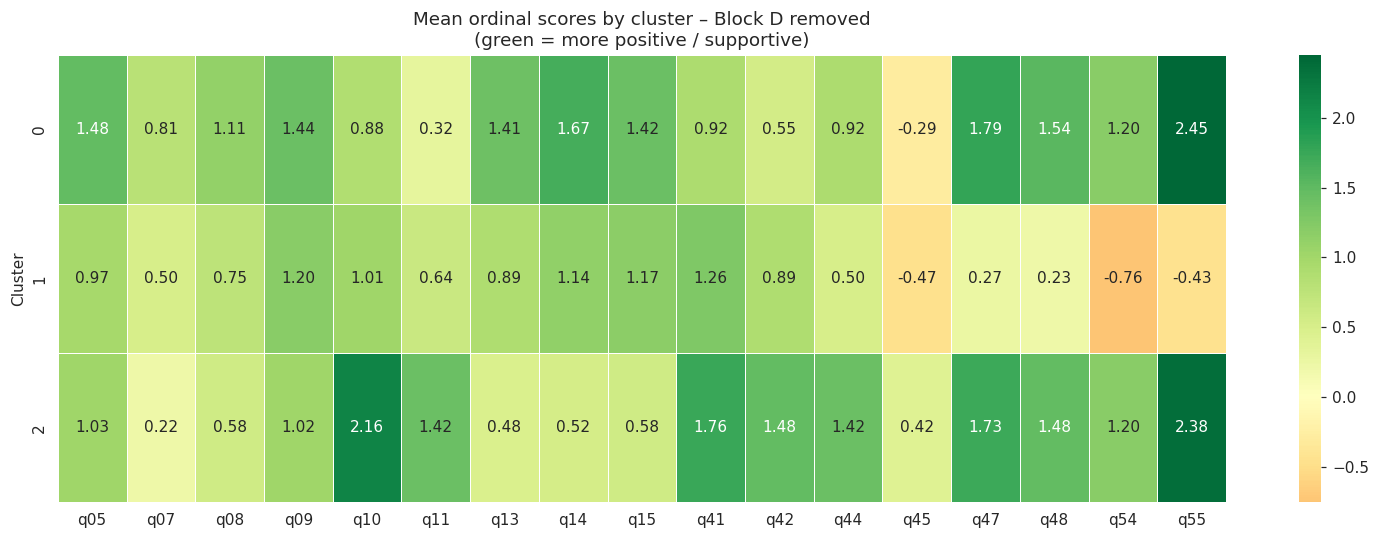

In [9]:

# Cell 8 — Heatmap of key variables (Block D removed)
heat_vars = [
    'q05', 'q07', 'q08', 'q09',          # formal support
    'q10', 'q11', 'q13', 'q14', 'q15',  # stigma & comfort
    'q41', 'q42', 'q44', 'q45',          # career stigma & unsupportive
    'q47', 'q48', 'q54', 'q55'           # MH history & interference
]

heat_vars = [v for v in heat_vars if v in X_cat.columns]

heat_data = X_cat.groupby('cluster')[heat_vars].mean()

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    heat_data,
    annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, ax=ax, linewidths=0.5
)
ax.set_title('Mean ordinal scores by cluster – Block D removed\n(green = more positive / supportive)')
ax.set_ylabel('Cluster')
plt.tight_layout()
plt.savefig(FIGDIR / 'cluster_profile_heatmap_no_blockD.png', bbox_inches='tight')
plt.show()

In [10]:

from scipy.stats import chi2_contingency, f_oneway

def cramers_v(contingency_table):
    """Calculates Cramér's V effect size for categorical association."""
    chi2 = chi2_contingency(contingency_table)[0]
    n = contingency_table.sum().sum()
    phi2 = chi2 / n
    r, k = contingency_table.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1)) / (n-1))
    rcorr = r - ((r-1)**2) / (n-1)
    kcorr = k - ((k-1)**2) / (n-1)
    return np.sqrt(phi2corr / max(1, (kcorr-1)*(rcorr-1)))

print("==========================================================")
print("     UPGRADED CLUSTER PROFILING & HYPOTHESIS TESTING      ")
print("==========================================================")

# 1. Cluster Sizes & Proportions
counts = context['cluster'].value_counts().sort_index()
props = (counts / len(context) * 100).round(1)
size_df = pd.DataFrame({'Count': counts, 'Percentage (%)': props})
print("\n--- 1. Cluster Size Distribution ---")
print(size_df)

# 2. ANOVA Test for Age (q56)
age_groups = [group['q56'].dropna() for _, group in context.groupby('cluster')]
f_stat, p_val_age = f_oneway(*age_groups)
print("\n--- 2. Age Profile ---")
age_summary = context.groupby('cluster')['q56'].agg(['mean', 'std', 'median']).round(1)
print(age_summary)
print(f"ANOVA Test for Age across clusters: F = {f_stat:.2f}, p-value = {p_val_age:.4f} {'(Significant)' if p_val_age < 0.05 else '(Not Significant)'}")

# 3. Categorical Variables Cross-Tabulation & Chi-Square Tests
cat_vars = {
    'q57': 'Gender Distribution',
    'q58': 'Country Distribution',
    'q63': 'Remote Work Status',
    'q25': 'Has Previous Employers'
}

print("\n--- 3. Categorical Demographic Associations ---")
stats_summary = []

for var_code, var_name in cat_vars.items():
    if var_code in context.columns:
        ct_raw = pd.crosstab(context['cluster'], context[var_code])
        ct_pct = (pd.crosstab(context['cluster'], context[var_code], normalize='index') * 100).round(1)
        
        # Calculate Chi-Square and Cramér's V
        chi2, p, dof, _ = chi2_contingency(ct_raw)
        effect_size = cramers_v(ct_raw)
        
        stats_summary.append({
            'Variable': var_name,
            'Chi2 Stat': round(chi2, 2),
            'p-value': round(p, 4),
            'Cramér\'s V': round(effect_size, 3),
            'Significant?': 'Yes (p < 0.05)' if p < 0.05 else 'No'
        })
        
        print(f"\n>>> {var_name} (% by Cluster) <<<")
        display(ct_pct)

# 4. Significance Summary Table
print("\n--- 4. Statistical Significance Summary Table ---")
sig_df = pd.DataFrame(stats_summary)
display(sig_df)

     UPGRADED CLUSTER PROFILING & HYPOTHESIS TESTING      

--- 1. Cluster Size Distribution ---
         Count  Percentage (%)
cluster                       
0          319            27.8
1          445            38.8
2          382            33.3

--- 2. Age Profile ---
         mean  std  median
cluster                   
0        33.9  8.4    32.0
1        32.8  7.3    32.0
2        33.8  8.2    33.0
ANOVA Test for Age across clusters: F = 2.33, p-value = 0.0978 (Not Significant)

--- 3. Categorical Demographic Associations ---

>>> Gender Distribution (% by Cluster) <<<


q57,Female,Male,Non-binary,Other,Prefer not to say
cluster,,,,,
0,25.4,69.3,0.3,4.7,0.3
1,15.5,82.7,0.0,1.8,0.0
2,29.1,65.7,1.8,2.9,0.5



>>> Country Distribution (% by Cluster) <<<


q58,Canada,Germany,Other,United Kingdom,United States of America
cluster,,,,,
0,2.5,2.8,11.9,11.3,71.5
1,7.9,4.7,21.1,13.3,53.0
2,5.2,3.7,16.8,10.2,64.1



>>> Remote Work Status (% by Cluster) <<<


q63,Always,Never,Sometimes
cluster,,,
0,22.6,20.4,57.1
1,20.4,29.4,50.1
2,14.1,31.9,53.9



>>> Has Previous Employers (% by Cluster) <<<


q25,0,1
cluster,,
0,7.2,92.8
1,13.9,86.1
2,12.0,88.0



--- 4. Statistical Significance Summary Table ---


,Variable,Chi2 Stat,p-value,Cramér's V,Significant?
0,Gender Distribution,45.29,0.0000,0.064,Yes (p < 0.05)
1,Country Distribution,33.20,0.0001,0.053,Yes (p < 0.05)
2,Remote Work Status,18.25,0.0011,0.056,Yes (p < 0.05)
3,Has Previous Employers,8.51,0.0142,0.053,Yes (p < 0.05)


## 6. Post-Clustering Demographic and Contextual Profile

To evaluate the real-world distinctiveness of the three employee clusters without introducing circular reasoning (Kaufman & Rousseeuw, 2009), the final cluster labels were cross-tabulated against secondary demographic and contextual variables that were held out during K-Means training.

Statistical significance across clusters was formally evaluated using One-Way Analysis of Variance (ANOVA) for continuous variables (age) and Chi-Square (χ²) Tests of Independence with Cramér's *V* effect size for categorical distributions (gender, country, remote work status, and employment history).

### Table 1: Demographic and Contextual Profile across Clusters (*N* = 1,146)

| Context Variable | Cluster 0: High-Burden / Supported (*n* = 319) | Cluster 1: Low-Burden Benchmark (*n* = 445) | Cluster 2: High-Burden + High Stigma (*n* = 382) | Test Statistic | *p*-value | Significance & Effect Size |
|---|---|---|---|---|---|---|
| **Mean Age (Years ± SD)** | 33.9 ± 8.4 | 32.8 ± 7.3 | 33.8 ± 8.2 | *F* = 2.33 | .0978 | Not Significant |
| **Gender Distribution (%)** | | | | χ² = 45.29 | < .0001 | **Significant** (*V* = .064) |
| — Female | 25.4% | 15.5% | **29.1%** | | | |
| — Male | 69.3% | **82.7%** | 65.7% | | | |
| — Non-binary / Other | 5.3% | 1.8% | 5.2% | | | |
| **Geographic Location (%)** | | | | χ² = 33.20 | .0001 | **Significant** (*V* = .053) |
| — United States | **71.5%** | 53.0% | 64.1% | | | |
| — United Kingdom | 11.3% | 13.3% | 10.2% | | | |
| — Canada & Germany | 5.3% | 12.6% | 8.9% | | | |
| — Other International | 11.9% | 21.1% | 16.8% | | | |
| **Work Arrangement (%)** | | | | χ² = 18.25 | .0011 | **Significant** (*V* = .056) |
| — Fully Remote (Always) | **22.6%** | 20.4% | 14.1% | | | |
| — Hybrid (Sometimes) | 57.1% | 50.1% | 53.9% | | | |
| — In-Office Only (Never) | 20.4% | 29.4% | **31.9%** | | | |
| **Has Previous Employers (%)** | **92.8%** | 86.1% | 88.0% | χ² = 8.51 | .0142 | **Significant** (*V* = .053) |

---

### Synthesized Empirical Findings for HR Strategy

#### 1. Intersectionality of Gender and Perceived Stigma

Gender distribution exhibits a highly statistically significant association with cluster membership (χ² = 45.29, *p* < .0001). Cluster 2 (High-Burden + High Stigma) contains the highest proportion of female (29.1%) and non-binary/gender-minority (5.2%) respondents, whereas Cluster 1 (Low-Burden Benchmark) is overwhelmingly male-dominated (82.7%). This demonstrates that negative career perceptions, lack of supervisor comfort, and feared mental-health stigma disproportionately affect underrepresented gender groups within technology organizations.

#### 2. Remote Work Flexibility as a Protective Structural Buffer

Work arrangement varies significantly across segments (χ² = 18.25, *p* = .0011). Employees in Cluster 2 report the highest full-time in-office requirement (31.9% never work remotely) and the lowest full-time remote participation (14.1%). Conversely, Cluster 0 employees utilize full remote arrangements at the highest rate (22.6%). This structural contrast suggests that remote work options may act as a protective mechanism for health-burdened staff by offering autonomy away from non-supportive micro-climates.

#### 3. Age Invariance

A One-Way ANOVA confirms that age differences across clusters are not statistically significant (*F*(2, 1143) = 2.33, *p* = .0978). Mean age remains stable at approximately 33 to 34 years across all groups. This indicates that workplace mental-health challenges and psychological safety perceptions are driven by organizational culture, policy, and manager behavior rather than generational cohorts.

#### 4. Geographic and Market Distribution

Domestic US employees are heavily concentrated in the high-burden groups (Cluster 0: 71.5%; Cluster 2: 64.1%), whereas Cluster 1 contains a substantially higher share of international respondents (47.0% non-US). This variance (χ² = 33.20, *p* = .0001) reflects structural differences in national healthcare systems, regulatory leave frameworks, and corporate support norms between US and non-US tech hubs.